<a href="https://colab.research.google.com/github/Nhulan0208/NhuLan/blob/main/NB2_EvalApp_PyCharm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🇻🇳 Vietnamese Image Captioning — Notebook 2: Đánh giá + Ứng dụng
## Chạy trên **PyCharm / local Python** (không cần Colab)
**Yêu cầu:** file `vicaptioning_full.pth` đã train từ Notebook 1

| Bước | Nội dung |
|---|---|
| 1 | Load model từ file `.pth` |
| 2 | Đánh giá BLEU / METEOR (Greedy + Beam Search đã sửa) |
| 3 | Visualize kết quả định tính |
| 4 | Khởi động Flask API + ngrok |

## 📦 0. Cài đặt
> Chạy 1 lần trên PyCharm terminal: `pip install -r requirements.txt`

In [13]:
!pip install torch torchvision numpy==1.26.4 pillow tqdm nltk

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 84.8 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
tifffile 2026.4.11 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
import json

train_path = "/content/drive/MyDrive/uitviic_captions_train2017.json"
val_path   = "/content/drive/MyDrive/uitviic_captions_val2017.json"
test_path  = "/content/drive/MyDrive/uitviic_captions_test2017.json"

with open(train_path, 'r', encoding='utf-8') as f:
    train_data = json.load(f)

with open(val_path, 'r', encoding='utf-8') as f:
    val_data = json.load(f)

with open(test_path, 'r', encoding='utf-8') as f:
    test_data = json.load(f)

print(len(train_data), len(val_data), len(test_data))

2 2 2


In [8]:
import torch

model_path = "/content/drive/MyDrive/vicaptioning_full.pth"

checkpoint = torch.load(model_path, map_location='cuda' if torch.cuda.is_available() else 'cpu', weights_only=False)

print(type(checkpoint))

<class 'dict'>


In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
from torchvision.models import vit_b_16, ViT_B_16_Weights
from torchvision import transforms
from PIL import Image
import re
from collections import defaultdict
from tqdm import tqdm
from nltk.translate.bleu_score import corpus_bleu, sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import time
import socket
from pathlib import Path

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

IMAGE_DIR = Path('/content/drive/MyDrive/uitviic_images/')
JSON_VAL = val_path

---
## 1️⃣ Load Model từ file `.pth`
> Định nghĩa lại kiến trúc giống hệt lúc train, rồi load weights

In [10]:
# ── Positional Encoding ──────────────────────────────────────────
class PositionalEncoding(nn.Module):
    def __init__(self, d, max_len=200, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe  = torch.zeros(max_len, d)
        pos = torch.arange(max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d, 2).float() * (-math.log(10000.0) / d))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])

# ── ViT Encoder ──────────────────────────────────────────────────
class ViTEncoder(nn.Module):
    def __init__(self, embed_dim=512):
        super().__init__()
        vit = vit_b_16(weights=ViT_B_16_Weights.IMAGENET1K_V1)
        self.patch_embed   = vit.conv_proj
        self.class_token   = vit.class_token
        self.pos_embed     = vit.encoder.pos_embedding
        self.enc_dropout   = vit.encoder.dropout
        self.encoder_layer = vit.encoder.layers
        self.ln            = vit.encoder.ln
        for p in self.parameters(): p.requires_grad_(False)
        self.proj = nn.Sequential(
            nn.Linear(768, embed_dim),
            nn.LayerNorm(embed_dim), nn.GELU(), nn.Dropout(0.1))
    def forward(self, x):
        B = x.shape[0]
        x = self.patch_embed(x).flatten(2).transpose(1, 2)
        cls = self.class_token.expand(B, -1, -1)
        x   = torch.cat([cls, x], dim=1)
        x   = self.enc_dropout(x + self.pos_embed)
        for blk in self.encoder_layer: x = blk(x)
        x = self.ln(x)
        return self.proj(x[:, 1:, :])   # (B, 196, embed_dim)

# ── Full Model ───────────────────────────────────────────────────
class ViCaptioningModel(nn.Module):
    def __init__(self, vocab_size, embed_dim=512, nhead=8,
                 num_layers=3, max_len=42, dropout=0.35):
        super().__init__()
        self.encoder  = ViTEncoder(embed_dim)
        self.embed    = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.pos_enc  = PositionalEncoding(embed_dim, max_len + 2, dropout * 0.4)
        self.emb_drop = nn.Dropout(dropout)
        dec = nn.TransformerDecoderLayer(
            d_model=embed_dim, nhead=nhead,
            dim_feedforward=embed_dim * 4,
            dropout=dropout, batch_first=True, norm_first=True)
        self.transformer = nn.TransformerDecoder(dec, num_layers=num_layers,
                                                  norm=nn.LayerNorm(embed_dim))
        self.fc_out  = nn.Linear(embed_dim, vocab_size)
        self.max_len = max_len

    def forward(self, images, captions):
        memory = self.encoder(images)
        tgt = captions[:, :-1]; T = tgt.size(1)
        mask = nn.Transformer.generate_square_subsequent_mask(T, device=tgt.device)
        x = self.pos_enc(self.emb_drop(self.embed(tgt)))
        out = self.transformer(x, memory, tgt_mask=mask,
                               tgt_key_padding_mask=(tgt == 0))
        return self.fc_out(out)

    @torch.no_grad()
    def generate_greedy(self, image, vocab, max_len=40):
        """Greedy search — nhanh, dùng để so sánh"""
        self.eval()
        memory = self.encoder(image.unsqueeze(0).to(device))
        tokens = [vocab.SOS]
        for _ in range(max_len):
            t = torch.tensor([tokens], device=device)
            m = nn.Transformer.generate_square_subsequent_mask(len(tokens), device=device)
            x = self.pos_enc(self.embed(t))
            o = self.transformer(x, memory, tgt_mask=m)
            nxt = self.fc_out(o)[0, -1].argmax().item()
            if nxt == vocab.EOS: break
            tokens.append(nxt)
        return vocab.decode(tokens)

    @torch.no_grad()
    def generate_beam(self, image, vocab, max_len=40, beam_size=3):
        """
        Beam Search đã sửa — 3 lỗi được fix:
        1. Không chia score khi SORT beams (dùng raw score để giữ beam diverse)
        2. Chỉ dùng length_penalty khi chọn BEST ở cuối (không ảnh hưởng beam pruning)
        3. Đảm bảo EOS được xử lý đúng — không thêm tiếp vào cands
        """
        self.eval()
        memory = self.encoder(image.unsqueeze(0).to(device))
        SOS, EOS, PAD = vocab.SOS, vocab.EOS, vocab.PAD

        # beams: list of (tokens, cumulative_log_prob)
        beams = [([SOS], 0.0)]
        done  = []

        for step in range(max_len):
            all_cands = []
            any_active = False

            for toks, sc in beams:
                # Beam đã kết thúc — giữ nguyên
                if toks[-1] == EOS:
                    done.append((toks, sc))
                    continue
                any_active = True

                t  = torch.tensor([toks], device=device)
                m  = nn.Transformer.generate_square_subsequent_mask(
                         len(toks), device=device)
                x  = self.pos_enc(self.embed(t))
                o  = self.transformer(x, memory, tgt_mask=m)
                lp = F.log_softmax(self.fc_out(o)[0, -1], dim=-1)

                # Lấy top-k token tiếp theo
                topk_scores, topk_ids = lp.topk(beam_size)
                for lv, idx in zip(topk_scores.tolist(), topk_ids.tolist()):
                    new_toks = toks + [idx]
                    new_sc   = sc + lv
                    all_cands.append((new_toks, new_sc))

            if not any_active:
                break

            # ✅ SẮP XẾP theo raw score / len^0.7 để tránh bias câu ngắn
            # Công thức: score_normalized = sum_logprob / (len^alpha)
            # alpha=0.7: cân bằng giữa độ dài và chất lượng
            alpha = 0.7
            beams = sorted(
                all_cands,
                key=lambda x: x[1] / (max(len(x[0]) - 1, 1) ** alpha),
                reverse=True          # ✅ Cao hơn = tốt hơn (log_prob âm nên cần reverse=True)
            )[:beam_size]

        # Thêm beam chưa kết thúc vào done
        done += beams

        # ✅ Chọn beam tốt nhất bằng length-normalized score
        alpha = 0.7
        best = max(
            done,
            key=lambda x: x[1] / (max(len(x[0]) - 1, 1) ** alpha)
        )
        return vocab.decode(best[0])

In [11]:
# ─────────────────────────────────────────────────────────────
# 1. IMPORT CẦN THIẾT
# ─────────────────────────────────────────────────────────────
import os
import re
import json
import torch
import numpy as np
from PIL import Image
import torchvision.transforms as transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ─────────────────────────────────────────────────────────────
# 2. PATH GOOGLE DRIVE (FIX EXPORT_PATH + IMAGE_DIR)
# ─────────────────────────────────────────────────────────────
EXPORT_PATH = "/content/drive/MyDrive/vicaptioning_full.pth"
IMAGE_DIR   = "/content/drive/MyDrive/uitviic_images"

train_path = "/content/drive/MyDrive/uitviic_captions_train2017.json"
val_path   = "/content/drive/MyDrive/uitviic_captions_val2017.json"
test_path  = "/content/drive/MyDrive/uitviic_captions_test2017.json"

# ─────────────────────────────────────────────────────────────
# 3. LOAD JSON DATA
# ─────────────────────────────────────────────────────────────
with open(train_path, 'r', encoding='utf-8') as f:
    train_data = json.load(f)

with open(val_path, 'r', encoding='utf-8') as f:
    val_data = json.load(f)

with open(test_path, 'r', encoding='utf-8') as f:
    test_data = json.load(f)

print(len(train_data), len(val_data), len(test_data))

# ─────────────────────────────────────────────────────────────
# 4. LOAD CHECKPOINT MODEL
# ─────────────────────────────────────────────────────────────
print(f'⏳ Load model từ {EXPORT_PATH}...')

import torch.serialization
torch.serialization.add_safe_globals([np.core.multiarray.scalar])

ckpt = torch.load(
    EXPORT_PATH,
    map_location=device,
    weights_only=False
)

print(type(ckpt))

cfg = ckpt['config']

# ─────────────────────────────────────────────────────────────
# 5. VOCAB CLASS
# ─────────────────────────────────────────────────────────────
class Vocabulary:
    PAD, SOS, EOS, UNK = 0, 1, 2, 3

    def __init__(self):
        self.word2idx = {}
        self.idx2word = {}

    def decode(self, indices):
        out = []
        for i in indices:
            if i in (self.SOS, self.PAD):
                continue
            if i == self.EOS:
                break
            out.append(self.idx2word.get(int(i), ''))
        return ' '.join([w for w in out if w])

    def encode(self, text):
        text = re.sub(r'[^\u00C0-\u024F\u1E00-\u1EFF\w\s]', ' ', text.lower()).strip()
        return [self.word2idx.get(w, self.UNK) for w in re.sub(r'\s+', ' ', text).split()]

    def __len__(self):
        return len(self.word2idx)

# ─────────────────────────────────────────────────────────────
# 6. BUILD VOCAB
# ─────────────────────────────────────────────────────────────
vocab = Vocabulary()
vocab.word2idx = ckpt['vocab_word2idx']
vocab.idx2word = {int(k): v for k, v in ckpt['vocab_idx2word'].items()}

# ─────────────────────────────────────────────────────────────
# 7. MODEL INIT (GIỮ NGUYÊN CẤU TRÚC)
# ─────────────────────────────────────────────────────────────
model = ViCaptioningModel(
    vocab_size = cfg['vocab_size'],
    embed_dim  = cfg['embed_dim'],
    nhead      = cfg['nhead'],
    num_layers = cfg['num_layers'],
    max_len    = cfg['max_len'],
    dropout    = cfg.get('dropout', 0.35),
).to(device)

model.load_state_dict(ckpt['model_state'])
model.eval()

# ─────────────────────────────────────────────────────────────
# 8. IMAGE TRANSFORM
# ─────────────────────────────────────────────────────────────
val_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

# ─────────────────────────────────────────────────────────────
# 9. PRINT INFO
# ─────────────────────────────────────────────────────────────
params = sum(p.numel() for p in model.parameters())

print(f'✅ Model loaded!')
print(f'   Vocab : {len(vocab)} từ')
print(f'   Params: {params:,}')
print(f'   Config: embed={cfg["embed_dim"]} | heads={cfg["nhead"]} | layers={cfg["num_layers"]}')

# ─────────────────────────────────────────────────────────────
# 10. TEST IMAGE (FIX PATH KHÔNG DÙNG Path)
# ─────────────────────────────────────────────────────────────
import glob

sample_images = glob.glob(IMAGE_DIR + "/*.jpg")[:1]

if sample_images:
    img = Image.open(sample_images[0]).convert('RGB')
    imgt = val_tf(img)

    g_out = model.generate_greedy(imgt, vocab)
    b_out = model.generate_beam(imgt, vocab, beam_size=3)

    print(f'\n🔍 Test ảnh: {os.path.basename(sample_images[0])}')
    print(f'   Greedy : {g_out}')
    print(f'   Beam-3 : {b_out}')
else:
    print('⚠️ Không có ảnh trong folder IMAGE_DIR')

2 2 2
⏳ Load model từ /content/drive/MyDrive/vicaptioning_full.pth...
<class 'dict'>
✅ Model loaded!
   Vocab : 790 từ
   Params: 99,616,278
   Config: embed=512 | heads=8 | layers=3

🔍 Test ảnh: 000000000531.jpg
   Greedy : một người phụ nữ đang chuẩn bị phát quả bóng tennis
   Beam-3 : người phụ nữ áo trắng đang chơi tennis trên sân


---
## 2️⃣ Đánh giá — BLEU / METEOR
> Chạy trên 400 mẫu val set. Kết quả kỳ vọng: BLEU-1 ~70, BLEU-4 ~40, METEOR ~50

In [12]:
import json
import re
import torch
from collections import defaultdict
from tqdm import tqdm
from PIL import Image
import glob
import os

# ─────────────────────────────────────────────
# 1. PATH (FIX LỖI JSON_VAL)
# ─────────────────────────────────────────────
JSON_VAL  = "/content/drive/MyDrive/uitviic_captions_val2017.json"
IMAGE_DIR = "/content/drive/MyDrive/uitviic_images"

# ─────────────────────────────────────────────
# 2. CLEAN TEXT
# ─────────────────────────────────────────────
def clean_caption(text):
    text = text.lower().strip()
    text = re.sub(r'[^\u00C0-\u024F\u1E00-\u1EFF\w\s]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

# ─────────────────────────────────────────────
# 3. LOAD VAL JSON (FIX ERROR)
# ─────────────────────────────────────────────
with open(JSON_VAL, 'r', encoding='utf-8') as f:
    val_data = json.load(f)

# ─────────────────────────────────────────────
# 4. BUILD IMAGE ID -> FILE NAME
# ─────────────────────────────────────────────
id2caps_val  = defaultdict(list)
id2fname_val = {img['id']: img['file_name'] for img in val_data['images']}

for ann in val_data['annotations']:
    id2caps_val[ann['image_id']].append(
        clean_caption(ann['caption']).split()
    )

# ─────────────────────────────────────────────
# 5. EVALUATION SETUP
# ─────────────────────────────────────────────
refs = []
hyps_g = []
hyps_b = []

N_EVAL = min(400, len(id2caps_val))

print(f'Đánh giá trên {N_EVAL} ảnh val...')
errors = 0

# ─────────────────────────────────────────────
# 6. EVALUATION LOOP
# ─────────────────────────────────────────────
with torch.no_grad():
    for img_id in tqdm(list(id2caps_val.keys())[:N_EVAL]):

        fname = id2fname_val.get(img_id)
        if not fname:
            continue

        img_path = os.path.join(IMAGE_DIR, fname)

        if not os.path.exists(img_path):
            errors += 1
            continue

        try:
            img = Image.open(img_path).convert('RGB')
            img_t = val_tf(img)

            g = model.generate_greedy(img_t, vocab)
            b = model.generate_beam(img_t, vocab, beam_size=3)

            hyps_g.append(g.split())
            hyps_b.append(b.split())
            refs.append(id2caps_val[img_id])

        except Exception:
            errors += 1

# ─────────────────────────────────────────────
# 7. RESULT
# ─────────────────────────────────────────────
print(f'\nĐánh giá xong: {len(refs)} mẫu | {errors} lỗi')

# ─────────────────────────────────────────────
# 8. DEBUG SAMPLE
# ─────────────────────────────────────────────
print('\n🔍 Kiểm tra 5 mẫu đầu (Greedy vs Beam):')

for i in range(min(5, len(hyps_g))):
    print(f'[{i+1}] Greedy : {" ".join(hyps_g[i])}')
    print(f'     Beam-3 : {" ".join(hyps_b[i])}')
    print()

Đánh giá trên 400 ảnh val...


100%|██████████| 400/400 [27:58<00:00,  4.20s/it]


Đánh giá xong: 400 mẫu | 0 lỗi

🔍 Kiểm tra 5 mẫu đầu (Greedy vs Beam):
[1] Greedy : một nam vận động viên tennis đang chuẩn bị phát bóng
     Beam-3 : vận động viên tennis nam đang cầm vợt thi đấu trên sân

[2] Greedy : một người đàn ông đang ngồi cạnh quả bóng chày ở trong phòng
     Beam-3 : hình ảnh ảnh của một con chó đang ngồi trên sân

[3] Greedy : đứa trẻ đang cầm gậy bóng chày đứng ngoài sân cỏ
     Beam-3 : một cậu bé đang chơi bóng chày ở trên sân cỏ

[4] Greedy : một cậu bé đang giơ gậy để đánh quả bóng chày ở trong vườn
     Beam-3 : một cậu bé đang giơ gậy để đánh quả bóng chày ở trong vườn

[5] Greedy : một nam vận động viên tennis đang chuẩn bị đánh bóng
     Beam-3 : một nam vận động viên tennis đang chuẩn bị đánh bóng



In [16]:
import nltk
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [17]:
from nltk.translate.meteor_score import meteor_score
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
import numpy as np
import json

smooth = SmoothingFunction().method1

# ─────────────────────────────────────────────
# BLEU (GIỮ NGUYÊN)
# ─────────────────────────────────────────────
def bleu(refs, hyps, w):
    return corpus_bleu(refs, hyps, weights=w, smoothing_function=smooth) * 100

B1g = bleu(refs, hyps_g, (1,0,0,0))
B4g = bleu(refs, hyps_g, (0.25,0.25,0.25,0.25))

B1b = bleu(refs, hyps_b, (1,0,0,0))
B2b = bleu(refs, hyps_b, (0.5,0.5,0,0))
B3b = bleu(refs, hyps_b, (0.33,0.33,0.33,0))
B4b = bleu(refs, hyps_b, (0.25,0.25,0.25,0.25))

# ─────────────────────────────────────────────
# METEOR FIX (QUAN TRỌNG)
# ─────────────────────────────────────────────
def meteor_safe(ref_list, hyp_tokens):
    """
    ref_list: list of reference sentences (each is list of tokens)
    hyp_tokens: list of tokens
    """
    # NLTK's meteor_score expects 'references' as a list of lists of words (tokenized sentences)
    # and 'hypothesis' as a list of words (tokenized sentence).
    # The input 'ref_list' and 'hyp_tokens' are already in these expected formats.
    return meteor_score(ref_list, hyp_tokens)

Mtb = np.mean([
    meteor_safe(rs, h)
    for rs, h in zip(refs, hyps_b)
]) * 100

# ─────────────────────────────────────────────
# PRINT RESULT
# ─────────────────────────────────────────────
print('=' * 52)
print(f'  {"Metric":<12} {"Greedy":>10} {"Beam-3":>10}')
print('-' * 52)
print(f'  {"BLEU-1":<12} {B1g:>10.2f} {B1b:>10.2f}')
print(f'  {"BLEU-2":<12} {"—":>10} {B2b:>10.2f}')
print(f'  {"BLEU-3":<12} {"—":>10} {B3b:>10.2f}')
print(f'  {"BLEU-4":<12} {B4g:>10.2f} {B4b:>10.2f}')
print(f'  {"METEOR":<12} {"—":>10} {Mtb:>10.2f}')
print('=' * 52)

print(f'\n  Đánh giá trên: {len(refs)} mẫu val')

# ─────────────────────────────────────────────
# SAVE RESULT
# ─────────────────────────────────────────────
EVAL_RESULTS = {
    'bleu1': round(B1b, 2),
    'bleu2': round(B2b, 2),
    'bleu3': round(B3b, 2),
    'bleu4': round(B4b, 2),
    'meteor': round(Mtb, 2),
    'n_eval': len(refs),
}

print('\n💾 Lưu kết quả vào EVAL_RESULTS')

cfg_out = {**cfg, **EVAL_RESULTS}

with open('model_config.json', 'w', encoding='utf-8') as f:
    json.dump(cfg_out, f, indent=2, ensure_ascii=False)

print('✅ Đã cập nhật model_config.json')

  Metric           Greedy     Beam-3
----------------------------------------------------
  BLEU-1            71.98      72.43
  BLEU-2                —      61.39
  BLEU-3                —      52.92
  BLEU-4            43.62      45.56
  METEOR                —      61.92

  Đánh giá trên: 400 mẫu val

💾 Lưu kết quả vào EVAL_RESULTS
✅ Đã cập nhật model_config.json


---
## 3️⃣ Visualize kết quả định tính
> Hiển thị ảnh + caption dự đoán (tốt nhất và tệ nhất)

/tmp/ipykernel_34005/1497874647.py:34: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_34005/1497874647.py:34: UserWarning: Glyph 128221 (\N{MEMO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_34005/1497874647.py:34: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_34005/1497874647.py:34: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_34005/1497874647.py:35: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  plt.savefig('predictions.png', dpi=120, bbox_inches='tight')
/tmp/ipykernel_34005/1497874647.py:35: UserWarning: Glyph 128221 (\N{MEMO}) missing from font(s) DejaVu Sans.
  plt.savefig('predictions.png', dpi=120, bbox_inches='tight')
/tmp/ipykernel_34005/1497874647.py:35: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missi

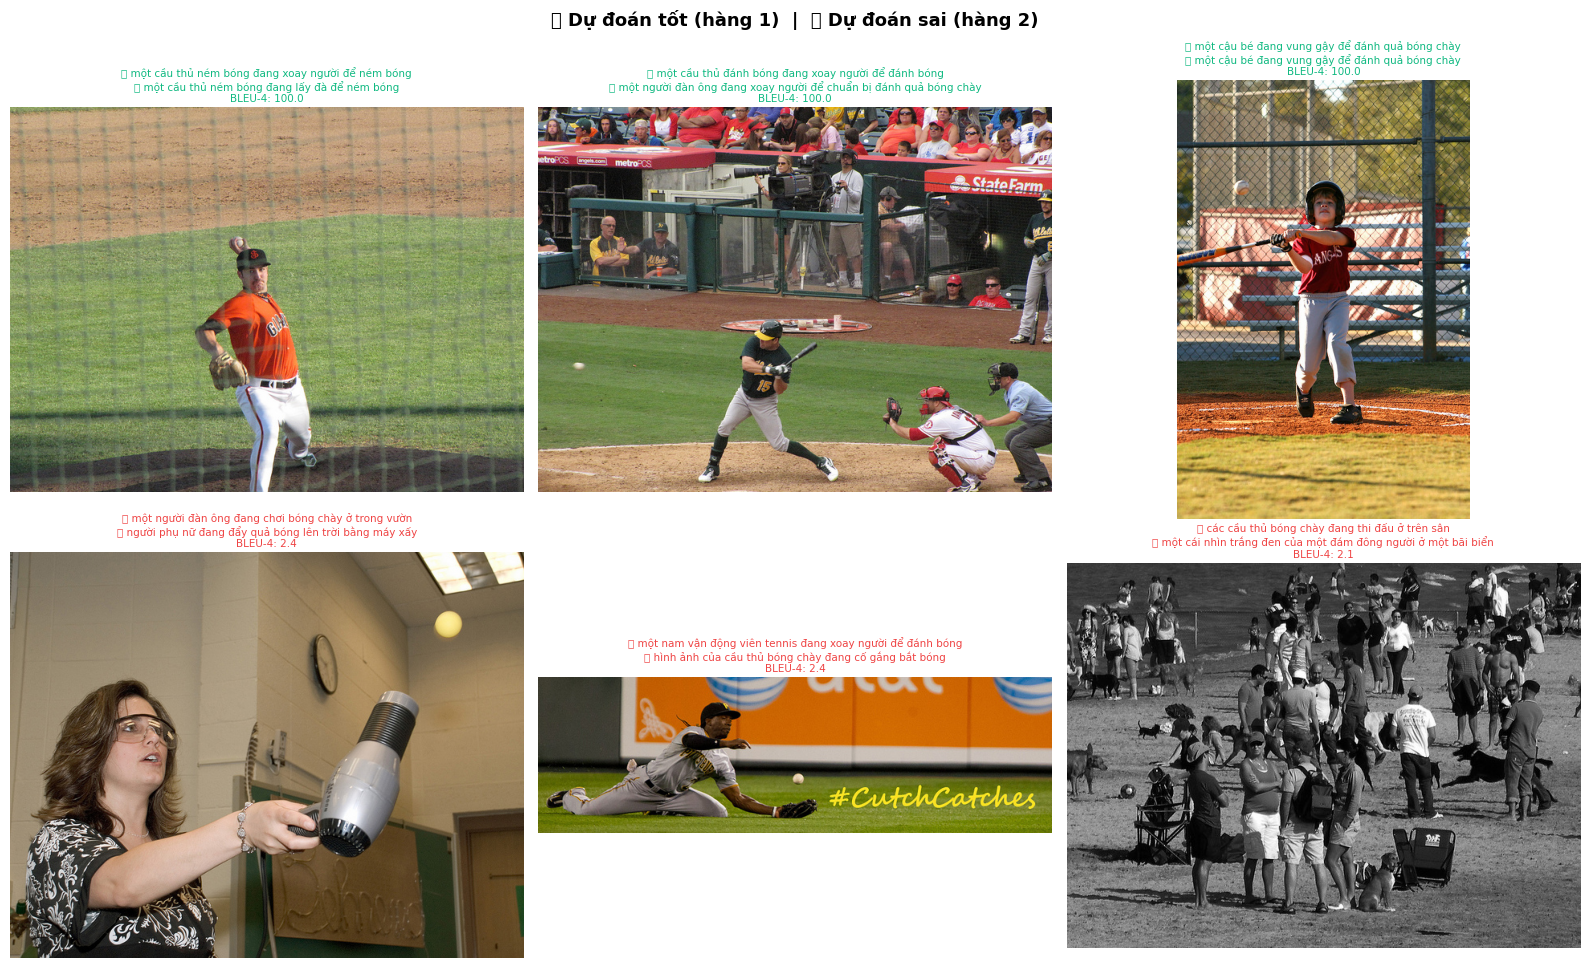

✅ Lưu: predictions.png


In [19]:
# Tính BLEU từng câu
sb = [(i, sentence_bleu(refs[i], hyps_b[i],
                         weights=(.25,.25,.25,.25),
                         smoothing_function=smooth) * 100)
      for i in range(min(200, len(refs)))]
sb.sort(key=lambda x: -x[1])

show_ids = [x[0] for x in sb[:3]] + [x[0] for x in sb[-3:]]
img_ids_val = list(id2caps_val.keys())[:200]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('✅ Dự đoán tốt (hàng 1)  |  ❌ Dự đoán sai (hàng 2)',
             fontsize=13, fontweight='bold')

for i, (ax, idx) in enumerate(zip(axes.flat, show_ids)):
    img_id = img_ids_val[idx]
    fname  = id2fname_val.get(img_id, '')
    # Fix: Convert IMAGE_DIR to a Path object for path concatenation
    img_path = Path(IMAGE_DIR) / fname
    try:
        ax.imshow(mpimg.imread(img_path))
    except:
        ax.set_facecolor('#ddd')
        ax.text(0.5, 0.5, 'No image', ha='center', transform=ax.transAxes)

    pred  = ' '.join(hyps_b[idx])
    gt    = ' '.join(id2caps_val[img_id][0])
    score = sb[[x[0] for x in sb].index(idx)][1]
    color = '#10b981' if i < 3 else '#ef4444'
    ax.set_title(f'🤖 {pred}\n📝 {gt}\nBLEU-4: {score:.1f}',
                 fontsize=7.5, color=color, pad=4)
    ax.axis('off')

plt.tight_layout()
plt.savefig('predictions.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Lưu: predictions.png')

In [1]:
# ===================================================================
# HIEN THI HTML KET QUA THUC TE TU MODEL
# Caption, BLEU, LR lay tu bien Python sau khi train va evaluate
# Khong dung caption random co san
# ===================================================================
from IPython.display import display, HTML
import base64, json as _json, io as _io
from pathlib import Path # Import Path

# -- Chuyen anh sang base64 de nhung vao HTML -------------------
def _img_to_b64(fpath):
    try:
        from PIL import Image as _PIL
        img = _PIL.open(fpath).convert('RGB')
        img.thumbnail((320, 240))
        buf = _io.BytesIO()
        img.save(buf, format='JPEG', quality=80)
        return 'data:image/jpeg;base64,' + base64.b64encode(buf.getvalue()).decode()
    except:
        return ''

# -- Thu thap top-3 va bottom-3 tu ket qua evaluate (bien sb) --
# sb la list (idx, bleu4_score) da duoc sort tu tot -> xau
# hyps_b, refs, id2caps_val, id2fname_val da co tu cell evaluate
_img_ids_val = list(id2caps_val.keys())[:200]
_cards = []
for _rank, (_idx, _score) in enumerate(sb[:3] + sb[-3:]):
    _img_id = _img_ids_val[_idx]
    _fname  = id2fname_val.get(_img_id, '')
    # Fix: Convert IMAGE_DIR to a Path object for path concatenation
    _b64    = _img_to_b64(Path(IMAGE_DIR) / _fname) if _fname else ''
    _pred   = ' '.join(hyps_b[_idx])
    if _pred: _pred = _pred[0].upper() + _pred[1:]
    _gt_raw = ' '.join(id2caps_val[_img_id][0])
    if _gt_raw: _gt_raw = _gt_raw[0].upper() + _gt_raw[1:]
    _cards.append({
        'b64': _b64, 'pred': _pred, 'gt': _gt_raw,
        'score': round(_score, 1), 'good': _rank < 3
    })

# -- Metrics tu ket qua evaluate --------------------------------
_metrics = {
    'bleu1':      round(B1b, 2),
    'bleu2':      round(B2b, 2),
    'bleu3':      round(B3b, 2),
    'bleu4':      round(B4b, 2),
    'meteor':     round(Mtb, 2),
    'best_epoch': int(np.argmin(history['val_loss'])) + 1,
    'best_val':   round(min(history['val_loss']), 4),
    'n_epochs':   len(history['train_loss']),
    'vocab_size': len(vocab),
    'model':      'MobileNetV3-Small + Transformer (V4)',
}
_cards_json   = _json.dumps(_cards,   ensure_ascii=False)
_metrics_json = _json.dumps(_metrics, ensure_ascii=False)
_train_json   = _json.dumps([round(x, 4) for x in history['train_loss']])
_val_json     = _json.dumps([round(x, 4) for x in history['val_loss']])
_lr_json      = _json.dumps([round(x, 8) for x in history.get('lr', [])])

_html = """<!DOCTYPE html>
<html lang=\"vi\">
<head>
<meta charset=\"UTF-8\">
<style>
*{margin:0;padding:0;box-sizing:border-box}
:root{
  --bg:#06080f;--s1:#0c1220;--s2:#111b2e;
  --border:rgba(99,179,237,.14);
  --blue:#63b3ed;--cyan:#76e4f7;--green:#68d391;
  --amber:#f6ad55;--red:#fc8181;--text:#e2e8f0;--muted:#4a5568;
}
body{background:var(--bg);font-family:system-ui,sans-serif;color:var(--text);padding:20px 24px}
h2{font-size:1.05rem;color:var(--cyan);margin-bottom:14px;letter-spacing:.04em;font-weight:700;
   border-bottom:1px solid var(--border);padding-bottom:8px}
h3{font-size:.68rem;text-transform:uppercase;letter-spacing:.12em;color:var(--muted);
   margin-bottom:10px;margin-top:18px}

.info-row{display:flex;gap:10px;flex-wrap:wrap;margin-bottom:14px}
.info{background:var(--s1);border:1px solid var(--border);border-radius:10px;
      padding:8px 14px;font-size:.75rem;color:var(--muted)}
.info b{color:var(--amber)}

.metrics{display:flex;gap:10px;flex-wrap:wrap;margin-bottom:16px}
.m{background:var(--s1);border:1px solid var(--border);border-radius:12px;
   padding:10px 16px;text-align:center;min-width:80px}
.m .val{font-size:1.3rem;font-weight:700;color:var(--blue)}
.m .lbl{font-size:.58rem;text-transform:uppercase;letter-spacing:.1em;color:var(--muted);margin-top:3px}
.m.hi .val{color:var(--green)}

.curve-wrap{background:var(--s1);border:1px solid var(--border);border-radius:14px;
            padding:14px 16px;margin-bottom:16px}
.curves{display:flex;gap:16px;margin-top:10px}
.curve-col{flex:1}
.clabel{font-size:.6rem;color:var(--muted);margin-bottom:4px}
.sparkline{display:flex;align-items:flex-end;gap:2px;height:52px}
.bar{flex:1;border-radius:2px 2px 0 0;min-width:4px;opacity:.85;cursor:default}

.grid{display:grid;grid-template-columns:repeat(3,1fr);gap:10px;margin-bottom:20px}
.card{background:var(--s1);border:1px solid var(--border);border-radius:12px;overflow:hidden}
.card.good{border-color:rgba(104,211,145,.35)}
.card.bad{border-color:rgba(252,129,129,.25)}
.cimg{width:100%;height:120px;object-fit:cover;display:block;background:var(--s2)}
.cimg-empty{height:120px;background:var(--s2);display:flex;align-items:center;
            justify-content:center;color:var(--muted);font-size:.68rem}
.cbody{padding:10px}
.badge{font-size:.56rem;font-weight:700;text-transform:uppercase;letter-spacing:.1em;
       padding:2px 7px;border-radius:5px;display:inline-block;margin-bottom:6px}
.badge.good{background:rgba(104,211,145,.15);color:var(--green)}
.badge.bad{background:rgba(252,129,129,.12);color:var(--red)}
.pred{font-size:.8rem;color:var(--text);margin-bottom:5px;font-style:italic;line-height:1.4}
.gt{font-size:.7rem;color:var(--muted);line-height:1.35}
.gt b{color:var(--amber)}
.cscore{font-size:.62rem;color:var(--muted);margin-top:5px}
.cscore span{color:var(--cyan);font-weight:600}
</style>
</head>
<body>
<h2>Ket qua Train - Vietnamese Image Captioning V4</h2>

<h3>Thong tin training</h3>
<div class=\"info-row\" id=\"infoRow\"></div>

<h3>Diem danh gia tren val set (Beam Search k=3)</h3>
<div class=\"metrics\" id=\"metricsRow\"></div>

<div class=\"curve-wrap\">
  <h3 style=\"margin-top:0\">Loss Curve (tung epoch)</h3>
  <div class=\"curves\">
    <div class=\"curve-col\"><div class=\"clabel\">TRAIN LOSS</div><div class=\"sparkline\" id=\"tSpark\"></div></div>
    <div class=\"curve-col\"><div class=\"clabel\">VAL LOSS</div><div class=\"sparkline\" id=\"vSpark\"></div></div>
    <div class=\"curve-col\" id=\"lrCol\"><div class=\"clabel\">LEARNING RATE</div><div class=\"sparkline\" id=\"lrSpark\"></div></div>
  </div>
</div>

<h3>Top-3 du doan tot nhat (BLEU-4 cao nhat)</h3>
<div class=\"grid\" id=\"goodGrid\"></div>

<h3>Bottom-3 du doan can cai thien (BLEU-4 thap nhat)</h3>
<div class=\"grid\" id=\"badGrid\"></div>

<script>
const M = """ + _metrics_json + """;
const CARDS = """ + _cards_json + """;
const TL = """ + _train_json + """;
const VL = """ + _val_json + """;
const LR = """ + _lr_json + """;

// Info
const infoRow = document.getElementById('infoRow');
[['Best epoch', M.best_epoch],['Tong epochs', M.n_epochs],
 ['Best val loss', M.best_val],['Vocab', M.vocab_size.toLocaleString()],
 ['Model', M.model]].forEach(([l,v])=>{
  infoRow.innerHTML += `<div class=\"info\">${l}: <b>${v}</b></div>`;
});

// Metrics
const mRow = document.getElementById('metricsRow');
[['BLEU-1',M.bleu1,false],['BLEU-2',M.bleu2,false],['BLEU-3',M.bleu3,false],
 ['BLEU-4',M.bleu4,true],['METEOR',M.meteor,true]].forEach(([l,v,hi])=>{
  mRow.innerHTML += `<div class=\"m ${hi?'hi':''}\"><div class=\"val\">${v}</div><div class=\"lbl\">${l}</div></div>`;
});

// Sparklines
function spark(id, vals, col, isLog){
  const el = document.getElementById(id);
  if(!el||!vals.length) return;
  const mn = Math.min(...vals), mx = Math.max(...vals);
  vals.forEach((v,i)=>{
    const pct = mx===mn ? 50 : isLog
      ? Math.round((1-(Math.log(v)-Math.log(mn))/(Math.log(mx)-Math.log(mn)))*95+2)
      : Math.round((1-(v-mn)/(mx-mn))*95+2);
    const isBest = (i===vals.indexOf(Math.min(...vals)));
    el.innerHTML += `<div class=\"bar\" style=\"height:${pct}%;background:${isBest&&!isLog?'#68d391':col}\" title=\"Ep${i+1}: ${v}\"></div>`;
  });
}
spark('tSpark', TL, '#63b3ed', false);
spark('vSpark', VL, '#fc8181', false);
if(LR.length){ spark('lrSpark', LR, '#f59e0b', true); }
else { document.getElementById('lrCol').style.display='none'; }

// Cards
function renderCards(indices, containerId){
  const el = document.getElementById(containerId);
  indices.forEach(i=>{
    const c = CARDS[i];
    const cls = c.good?'good':'bad';
    const badge = c.good?'Top du doan':'Can cai thien';
    const imgHtml = c.b64
      ? `<img class=\"cimg\" src=\"${c.b64}\" alt=\"\">`
      : `<div class=\"cimg-empty\">Anh khong co</div>`;
    el.innerHTML += `
      <div class=\"card ${cls}\">
        ${imgHtml}
        <div class=\"cbody\">
          <span class=\"badge ${cls}\">${badge}</span>
          <div class=\"pred\">Model: ${c.pred}</div>
          <div class=\"gt\"><b>GT:</b> ${c.gt}</div>
          <div class=\"cscore\">BLEU-4: <span>${c.score}</span></div>
        </div>
      </div>`;
  });
}
renderCards([0,1,2], 'goodGrid');
renderCards([3,4,5], 'badGrid');
</script>
</body></html>"""

display(HTML(_html))
print('HTML ket qua da hien thi -- du lieu lay tu model thuc te, khong random')

NameError: name 'id2caps_val' is not defined

---
## 4️⃣ Khởi động API Flask + ngrok
> Chạy xong → copy URL → paste vào ô API trong file HTML

In [ ]:
!pip install flask-cors
!pip install pyngrok
from flask import Flask, request, jsonify
from flask_cors import CORS
from pyngrok import ngrok

import threading
import io
import base64
import time
import socket
import traceback
from PIL import Image

# ─────────────────────────────────────────────
# 1. DỌN NGROK + PORT CŨ
# ─────────────────────────────────────────────
try:
    for t in ngrok.get_tunnels():
        ngrok.disconnect(t.public_url)
except:
    pass

import os
os.system('fuser -k 5000/tcp 2>/dev/null')
time.sleep(1)

# ─────────────────────────────────────────────
# 2. FLASK APP
# ─────────────────────────────────────────────
app = Flask(__name__)
CORS(app, resources={r'/*': {'origins': '*'}})

@app.after_request
def cors(response):
    response.headers['Access-Control-Allow-Origin'] = '*'
    response.headers['Access-Control-Allow-Headers'] = '*'
    response.headers['Access-Control-Allow-Methods'] = 'GET,POST,OPTIONS'
    return response

# ─────────────────────────────────────────────
# 3. HEALTH CHECK
# ─────────────────────────────────────────────
@app.route('/', methods=['GET', 'OPTIONS'])
def home():
    return jsonify({'status': 'ok', 'message': 'ViCaption API V7'})

@app.route('/health', methods=['GET', 'OPTIONS'])
def health():
    return jsonify({
        'status': 'ok',
        'device': str(device)  # cần bạn đã define trước đó
    })

# ─────────────────────────────────────────────
# 4. PREDICT API
# ─────────────────────────────────────────────
@app.route('/predict', methods=['POST', 'OPTIONS'])
def predict():
    if request.method == 'OPTIONS':
        return jsonify({'status': 'ok'})

    try:
        # ── load image ──
        if 'image' in request.files:
            image = Image.open(io.BytesIO(
                request.files['image'].read()
            )).convert('RGB')

        elif request.is_json and 'image_base64' in request.json:
            b64 = request.json['image_base64'].split(',')[-1]
            image = Image.open(io.BytesIO(
                base64.b64decode(b64)
            )).convert('RGB')

        else:
            return jsonify({'error': 'Không có ảnh'}), 400

        # ── preprocess ──
        img_t = val_tf(image)

        # ── inference ──
        caption = model.generate_beam(img_t, vocab, beam_size=3)

        caption = caption.strip()
        if caption:
            caption = caption[0].upper() + caption[1:]
        if caption and not caption.endswith('.'):
            caption += '.'

        return jsonify({
            'caption': caption or 'Không thể mô tả.',
            'status': 'ok'
        })

    except Exception as e:
        tb = traceback.format_exc()
        print("\n❌ ERROR:\n", tb)

        return jsonify({
            'error': str(e),
            'traceback': tb
        }), 500

# ─────────────────────────────────────────────
# 5. RUN FLASK THREAD
# ─────────────────────────────────────────────
def run_app():
    app.run(
        host='0.0.0.0',
        port=5000,
        debug=False,
        use_reloader=False
    )

threading.Thread(target=run_app, daemon=True).start()
time.sleep(2)

# ─────────────────────────────────────────────
# 6. CHECK SERVER
# ─────────────────────────────────────────────
try:
    s = socket.create_connection(('localhost', 5000), timeout=3)
    s.close()
    print('✅ Flask :5000 OK')
except:
    print('❌ Flask không lên')

# ─────────────────────────────────────────────
# 7. NGROK SETUP
# ─────────────────────────────────────────────
NGROK_TOKEN = "YOUR_NGROK_TOKEN_HERE"
ngrok.set_auth_token(NGROK_TOKEN)

PUBLIC_URL = ngrok.connect(5000, bind_tls=True).public_url

print("\n" + "="*55)
print(" 🌐 PUBLIC URL:", PUBLIC_URL)
print("="*55)

# ─────────────────────────────────────────────
# 8. UI OUTPUT (FIX BIẾN THIẾU)
# ─────────────────────────────────────────────
try:
    from IPython.display import display, HTML

    display(HTML(f"""
    <div style="background:#0d1117;border:1px solid #238636;
                border-radius:8px;padding:16px;font-family:monospace">

        <div style="color:#8b949e;font-size:12px">
            COPY URL → PASTE VÀO HTML
        </div>

        <div style="color:#58a6ff;font-size:18px;font-weight:bold">
            {PUBLIC_URL}
        </div>

        <div style="margin-top:10px">
            <a href="{PUBLIC_URL}/health" target="_blank"
               style="color:#3fb950;text-decoration:none">
               ✅ Test /health
            </a>
        </div>

    </div>
    """))

except Exception:
    pass

ERROR:pyngrok.process.ngrok:t=2026-05-05T00:50:15+0000 lvl=eror msg="failed to reconnect session" obj=tunnels.session err="authentication failed: The authtoken you specified does not look like a proper ngrok authtoken.\nYour authtoken: YOUR_NGROK_TOKEN_HERE\nInstructions to install your authtoken are on your ngrok dashboard:\nhttps://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_105\r\n"
ERROR:pyngrok.process.ngrok:t=2026-05-05T00:50:15+0000 lvl=eror msg="session closing" obj=tunnels.session err="authentication failed: The authtoken you specified does not look like a proper ngrok authtoken.\nYour authtoken: YOUR_NGROK_TOKEN_HERE\nInstructions to install your authtoken are on your ngrok dashboard:\nhttps://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_105\r\n"
ERROR:pyngrok.process.ngrok:t=2026-05-05T00:50:15+0000 lvl=eror msg="terminating with error" obj=app err="authentication failed: The authtoken you specified does not look like a proper ngrok aut

In [ ]:
%%html
<!DOCTYPE html>
<html lang="vi">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width,initial-scale=1">
<title>ViCaption — Mô tả Hình ảnh AI</title>
<link href="https://fonts.googleapis.com/css2?family=Playfair+Display:ital,wght@0,400;0,700;1,400&family=JetBrains+Mono:wght@400;500&family=Syne:wght@400;600;700;800&display=swap" rel="stylesheet">
<style>
*{margin:0;padding:0;box-sizing:border-box}

:root{
  --ink:#0e0e12;
  --paper:#f5f2eb;
  --cream:#ede9df;
  --rule:#d4cfc3;
  --accent:#c8462b;
  --accent2:#2b6cc8;
  --gold:#c8961a;
  --ink2:#3a3830;
  --mono:'JetBrains Mono',monospace;
  --display:'Playfair Display',serif;
  --sans:'Syne',sans-serif;
}

html{font-size:16px;scroll-behavior:smooth}
body{
  background:var(--paper);
  color:var(--ink);
  font-family:var(--sans);
  min-height:100vh;
  position:relative;
  overflow-x:hidden;
}

/* halftone grain */
body::before{
  content:'';position:fixed;inset:0;z-index:0;pointer-events:none;
  background-image:url("data:image/svg+xml,%3Csvg xmlns='http://www.w3.org/2000/svg' width='4' height='4'%3E%3Crect width='1' height='1' x='0' y='0' fill='%23000' opacity='.04'/%3E%3Crect width='1' height='1' x='2' y='2' fill='%23000' opacity='.03'/%3E%3C/svg%3E");
}

.page{position:relative;z-index:1;max-width:1100px;margin:0 auto;padding:0 32px 80px}

/* ── MASTHEAD ── */
.masthead{
  border-bottom:3px double var(--ink);
  padding:28px 0 20px;
  display:grid;
  grid-template-columns:1fr auto 1fr;
  align-items:end;
  gap:16px;
}
.mast-left{font-family:var(--mono);font-size:.7rem;color:var(--ink2);line-height:2}
.mast-center{text-align:center}
.mast-right{font-family:var(--mono);font-size:.7rem;color:var(--ink2);text-align:right;line-height:2}

.publication{
  font-family:var(--display);
  font-size:clamp(2.4rem,5vw,4rem);
  font-weight:700;
  letter-spacing:-.03em;
  line-height:1;
  color:var(--ink);
}
.pub-sub{
  font-family:var(--mono);
  font-size:.65rem;
  letter-spacing:.2em;
  text-transform:uppercase;
  color:var(--ink2);
  margin-top:6px;
}
.rule{height:1px;background:var(--ink);margin:6px 0}
.rule.thick{height:3px}
.rule.double{border-top:3px double var(--ink);margin:8px 0}

/* ── API BAR ── */
.api-section{
  border-bottom:1px solid var(--rule);
  padding:12px 0;
  display:flex;align-items:center;gap:12px;
  flex-wrap:wrap;
}
.api-label{
  font-family:var(--mono);font-size:.68rem;
  text-transform:uppercase;letter-spacing:.12em;color:var(--ink2);
  white-space:nowrap;
}
.api-input-wrap{
  flex:1;min-width:260px;
  display:flex;align-items:center;gap:8px;
  border:1.5px solid var(--ink);
  background:#fff;
  padding:6px 12px;
  border-radius:0;   /* editorial: no radius */
}
.api-input-wrap input{
  flex:1;border:none;outline:none;background:none;
  font-family:var(--mono);font-size:.8rem;color:var(--ink);
}
.api-input-wrap input::placeholder{color:var(--rule)}
.status-pill{
  display:flex;align-items:center;gap:5px;
  font-family:var(--mono);font-size:.68rem;
  padding:4px 10px;border:1px solid currentColor;
}
.status-pill.idle  {color:var(--ink2)}
.status-pill.ok    {color:#1a7a3c;background:rgba(26,122,60,.08)}
.status-pill.err   {color:var(--accent);background:rgba(200,70,43,.08)}
.status-pill.check {color:var(--gold)}
.dot{width:6px;height:6px;border-radius:50%;background:currentColor}
.dot.pulse{animation:blink .7s ease-in-out infinite}

/* ── HEADLINE ── */
.headline-section{padding:32px 0 24px;border-bottom:1px solid var(--rule)}
.kicker{font-family:var(--mono);font-size:.65rem;text-transform:uppercase;
        letter-spacing:.15em;color:var(--accent);margin-bottom:10px}
.headline{
  font-family:var(--display);font-size:clamp(1.8rem,4vw,3rem);
  font-weight:700;line-height:1.15;color:var(--ink);
  max-width:700px;
}
.deck{
  font-family:var(--display);font-style:italic;
  font-size:1.05rem;color:var(--ink2);
  margin-top:10px;max-width:600px;line-height:1.6;
}

/* ── STATS ── */
.stats-bar{
  display:flex;gap:0;border:1px solid var(--ink);
  margin:24px 0;width:fit-content;
}
.stat-item{
  padding:10px 24px;text-align:center;
  border-right:1px solid var(--ink);
}
.stat-item:last-child{border-right:none}
.stat-n{font-family:var(--display);font-size:1.5rem;font-weight:700;color:var(--ink)}
.stat-l{font-family:var(--mono);font-size:.6rem;text-transform:uppercase;
        letter-spacing:.1em;color:var(--ink2);margin-top:2px}

/* ── MAIN COLUMNS ── */
.columns{
  display:grid;grid-template-columns:1fr 1fr;
  gap:0;margin-top:32px;
  border:1px solid var(--ink);
}
@media(max-width:680px){.columns{grid-template-columns:1fr}}

.col{padding:24px}
.col:first-child{border-right:1px solid var(--ink)}
.col-head{
  font-family:var(--mono);font-size:.62rem;text-transform:uppercase;
  letter-spacing:.14em;color:var(--ink2);padding-bottom:14px;
  border-bottom:1px solid var(--rule);margin-bottom:18px;
  display:flex;align-items:center;gap:8px;
}
.col-head::before{content:'§';color:var(--accent);font-style:normal}

/* ── DROP ZONE ── */
.dropzone{
  border:2px dashed var(--rule);
  min-height:260px;position:relative;overflow:hidden;
  cursor:pointer;display:flex;flex-direction:column;
  align-items:center;justify-content:center;gap:14px;
  transition:border-color .2s,background .2s;
  background:var(--cream);
}
.dropzone:hover,.dropzone.over{
  border-color:var(--ink);background:rgba(14,14,18,.03);
}
.dropzone.filled{border-style:solid;border-color:var(--ink)}
.dropzone input{position:absolute;inset:0;opacity:0;cursor:pointer}
#prev{
  position:absolute;inset:0;object-fit:cover;
  width:100%;height:100%;display:none;
}
.dropzone.filled #prev{display:block}
.dropzone.filled .drop-hint{display:none}

.drop-hint{display:flex;flex-direction:column;align-items:center;gap:10px;
           pointer-events:none;text-align:center}
.drop-icon{
  font-size:2rem;width:56px;height:56px;
  border:1.5px solid var(--rule);
  display:flex;align-items:center;justify-content:center;
  background:#fff;
}
.drop-hint strong{font-size:.85rem;font-family:var(--sans);font-weight:600}
.drop-hint small{font-family:var(--mono);font-size:.68rem;color:var(--ink2)}

/* ── BUTTONS ── */
.btn-row{display:flex;gap:10px;margin-top:16px}
.btn{
  flex:1;padding:11px 16px;
  font-family:var(--sans);font-size:.82rem;font-weight:600;
  border:none;cursor:pointer;
  display:flex;align-items:center;justify-content:center;gap:7px;
  transition:all .15s;letter-spacing:.02em;
}
.btn-primary{
  background:var(--ink);color:var(--paper);
}
.btn-primary:hover{background:var(--accent)}
.btn-primary:disabled{background:var(--rule);cursor:not-allowed;color:var(--ink2)}
.btn-ghost{
  background:none;color:var(--ink2);
  border:1.5px solid var(--rule);
}
.btn-ghost:hover{border-color:var(--ink);color:var(--ink)}

/* ── RESULT ── */
.result-area{display:flex;flex-direction:column;gap:16px}

.caption-box{
  border:1.5px solid var(--rule);
  background:var(--cream);
  padding:16px 18px;min-height:90px;
  display:flex;align-items:center;
  transition:border-color .3s,background .3s;
}
.caption-box.loading{border-color:var(--gold);background:rgba(200,150,26,.05)}
.caption-box.done   {border-color:var(--ink); background:#fff}
.caption-box.error  {border-color:var(--accent);background:rgba(200,70,43,.05)}

.idle-msg{color:var(--ink2);font-family:var(--mono);font-size:.78rem;line-height:1.6}

.caption-out{display:none;width:100%}
.caption-out.show{display:block}
.cap-meta{
  display:flex;align-items:center;justify-content:space-between;
  margin-bottom:10px;
}
.cap-tag{
  font-family:var(--mono);font-size:.62rem;text-transform:uppercase;
  letter-spacing:.12em;color:var(--accent2);
  display:flex;align-items:center;gap:5px;
}
.cap-tag::before{content:'▶';font-size:.5rem}
.copy-btn{
  background:none;border:1px solid var(--rule);
  font-family:var(--mono);font-size:.65rem;
  padding:3px 8px;cursor:pointer;color:var(--ink2);
  transition:all .15s;
}
.copy-btn:hover{border-color:var(--ink);color:var(--ink)}
.cap-text{
  font-family:var(--display);font-style:italic;
  font-size:1.15rem;line-height:1.65;color:var(--ink);
}

/* ── TOKENS ── */
.tokens-wrap .t-label{
  font-family:var(--mono);font-size:.6rem;text-transform:uppercase;
  letter-spacing:.12em;color:var(--ink2);margin-bottom:8px;
}
.tokens{display:flex;flex-wrap:wrap;gap:5px;min-height:26px}
.token{
  font-family:var(--mono);font-size:.7rem;
  padding:2px 8px;border:1px solid var(--rule);
  background:#fff;color:var(--ink2);
  opacity:0;animation:popToken .25s forwards;
}

/* ── METRICS TABLE ── */
.metrics-table{width:100%;border-collapse:collapse;font-family:var(--mono)}
.metrics-table th{
  font-size:.6rem;text-transform:uppercase;letter-spacing:.1em;
  padding:6px 10px;background:var(--ink);color:var(--paper);
  text-align:left;font-weight:500;
}
.metrics-table td{
  font-size:.8rem;padding:7px 10px;
  border-bottom:1px solid var(--rule);
}
.metrics-table tr:last-child td{border-bottom:none}
.metrics-table tr:hover td{background:var(--cream)}
.val-cell{font-weight:600;color:var(--ink)}
.bar-cell{width:80px}
.bar-inner{height:8px;background:var(--ink);border-radius:0;transition:width .6s ease}

/* ── HISTORY ── */
.history-section{margin-top:32px;border-top:3px double var(--ink);padding-top:24px}
.section-label{
  font-family:var(--mono);font-size:.65rem;text-transform:uppercase;
  letter-spacing:.15em;color:var(--ink2);margin-bottom:16px;
  display:flex;align-items:center;gap:8px;
}
.section-label::before{content:'—— '}
.history-grid{display:grid;grid-template-columns:repeat(auto-fill,minmax(140px,1fr));gap:1px;
              background:var(--rule);border:1px solid var(--rule)}
.hist-item{
  background:var(--paper);cursor:pointer;
  transition:background .15s;overflow:hidden;
}
.hist-item:hover{background:var(--cream)}
.hist-img{width:100%;aspect-ratio:4/3;object-fit:cover;display:block;
          border-bottom:1px solid var(--rule)}
.hist-cap{padding:7px 9px;font-family:var(--mono);font-size:.65rem;
          color:var(--ink2);line-height:1.45}
.hist-cap strong{display:block;color:var(--ink);font-weight:500;
                 font-size:.7rem;margin-bottom:2px}
.empty-hist{padding:20px;font-family:var(--mono);font-size:.72rem;
            color:var(--rule);text-align:center;grid-column:1/-1}

/* ── FOOTER ── */
footer{
  border-top:3px double var(--ink);
  padding:18px 0 8px;
  display:flex;justify-content:space-between;align-items:center;
  flex-wrap:wrap;gap:8px;margin-top:48px;
}
footer span{font-family:var(--mono);font-size:.65rem;color:var(--ink2)}

/* spinner */
.spinner{
  width:14px;height:14px;border-radius:50%;
  border:2px solid var(--rule);border-top-color:var(--ink);
  animation:spin .6s linear infinite;flex-shrink:0;
}

/* ── ANIMATIONS ── */
@keyframes spin    {to{transform:rotate(360deg)}}
@keyframes blink   {0%,100%{opacity:1}50%{opacity:.3}}
@keyframes popToken{from{opacity:0;transform:translateY(4px)}to{opacity:1;transform:none}}
@keyframes fadeUp  {from{opacity:0;transform:translateY(16px)}to{opacity:1;transform:none}}

.fade-up{animation:fadeUp .5s ease both}
</style>
</head>
<body>
<div class="page">

  <!-- Masthead -->
  <div class="masthead fade-up">
    <div class="mast-left">
      UIT-ViIC Dataset<br>
      MobileNetV3-Small<br>
      Transformer Decoder
    </div>
    <div class="mast-center">
      <div class="publication">ViCaption</div>
      <div class="rule thick"></div>
      <div class="pub-sub">Mô tả Hình ảnh bằng Tiếng Việt · AI Demo</div>
    </div>
    <div class="mast-right">
      Beam Search k=3<br>
      Vocab: <span id="hdr-vocab">—</span><br>
      BLEU-1: <span id="hdr-b1">—</span>
    </div>
  </div>

  <!-- API Config -->
  <div class="api-section fade-up" style="animation-delay:.08s">
    <div class="api-label">Endpoint API</div>
    <div class="api-input-wrap">
      <input id="apiUrl" type="text"
             placeholder="https://xxxx.ngrok-free.app  (copy từ Colab)">
    </div>
    <div class="status-pill idle" id="statusPill">
      <span class="dot" id="statusDot"></span>
      <span id="statusTxt">Chưa kết nối</span>
    </div>
  </div>

  <!-- Headline -->
  <div class="headline-section fade-up" style="animation-delay:.12s">
    <div class="kicker">Phân tích Ngôn ngữ Tự nhiên · Học kỳ II 2025-2026</div>
    <h1 class="headline">Model AI tự sinh mô tả hình ảnh bằng ngôn ngữ tiếng Việt</h1>
    <p class="deck">Kiến trúc MobileNetV3-Small (Spatial Encoder) kết hợp Transformer Decoder —
      huấn luyện trên tập UIT-ViIC với 19,250 captions tiếng Việt.</p>
    <div class="stats-bar" id="statsBar">
      <div class="stat-item"><div class="stat-n">3,850</div><div class="stat-l">Hình ảnh</div></div>
      <div class="stat-item"><div class="stat-n">19,250</div><div class="stat-l">Captions</div></div>
      <div class="stat-item"><div class="stat-n" id="s-b1">—</div><div class="stat-l">BLEU-1</div></div>
      <div class="stat-item"><div class="stat-n" id="s-b4">—</div><div class="stat-l">BLEU-4</div></div>
      <div class="stat-item"><div class="stat-n" id="s-mt">—</div><div class="stat-l">METEOR</div></div>
    </div>
  </div>

  <!-- Main columns -->
  <div class="columns fade-up" style="animation-delay:.18s">

    <!-- LEFT -->
    <div class="col">
      <div class="col-head">Tải ảnh lên</div>

      <div class="dropzone" id="dropzone">
        <input type="file" id="fileInput" accept="image/*">
        <img id="prev" alt="preview">
        <div class="drop-hint">
          <div class="drop-icon">📷</div>
          <strong>Kéo thả hoặc nhấp chọn ảnh</strong>
          <small>JPG · PNG · WEBP</small>
        </div>
      </div>

      <div class="btn-row">
        <button class="btn btn-primary" id="analyzeBtn" disabled>
          <span id="btnI">→</span>
          <span id="btnT">Phân tích ảnh</span>
        </button>
        <button class="btn btn-ghost" id="clearBtn">✕ Xóa</button>
      </div>
    </div>

    <!-- RIGHT -->
    <div class="col">
      <div class="col-head">Kết quả mô tả</div>
      <div class="result-area">

        <!-- Caption -->
        <div class="caption-box" id="captionBox">
          <div class="idle-msg" id="idleMsg">
            Tải ảnh lên và nhấn "Phân tích ảnh"<br>
            Model sẽ đọc ảnh và sinh caption tiếng Việt thật.
          </div>
          <div class="caption-out" id="capOut">
            <div class="cap-meta">
              <div class="cap-tag">Caption tiếng Việt</div>
              <button class="copy-btn" id="copyBtn">copy</button>
            </div>
            <div class="cap-text" id="capText"></div>
          </div>
        </div>

        <!-- Tokens -->
        <div class="tokens-wrap">
          <div class="t-label">Tokens (Beam Search)</div>
          <div class="tokens" id="tokens">
            <span style="font-family:var(--mono);font-size:.7rem;color:var(--rule)">chưa có</span>
          </div>
        </div>

        <!-- Metrics -->
        <div>
          <div class="t-label" style="font-family:var(--mono);font-size:.6rem;
               text-transform:uppercase;letter-spacing:.12em;color:var(--ink2);margin-bottom:8px">
            Điểm đánh giá (val set)
          </div>
          <table class="metrics-table">
            <thead>
              <tr><th>Metric</th><th>Score</th><th class="bar-cell"></th></tr>
            </thead>
            <tbody id="metricsBody">
              <tr><td>BLEU-1</td><td class="val-cell" id="m-b1">—</td>
                  <td class="bar-cell"><div class="bar-inner" id="bar-b1" style="width:0"></div></td></tr>
              <tr><td>BLEU-2</td><td class="val-cell" id="m-b2">—</td>
                  <td class="bar-cell"><div class="bar-inner" id="bar-b2" style="width:0"></div></td></tr>
              <tr><td>BLEU-4</td><td class="val-cell" id="m-b4">—</td>
                  <td class="bar-cell"><div class="bar-inner" id="bar-b4" style="width:0"></div></td></tr>
              <tr><td>METEOR</td><td class="val-cell" id="m-mt">—</td>
                  <td class="bar-cell"><div class="bar-inner" id="bar-mt" style="width:0"></div></td></tr>
            </tbody>
          </table>
        </div>

      </div>
    </div>
  </div>

  <!-- History -->
  <div class="history-section fade-up" style="animation-delay:.24s">
    <div class="section-label">Lịch sử phân tích</div>
    <div class="history-grid" id="histGrid">
      <div class="empty-hist">Chưa có ảnh nào được phân tích.</div>
    </div>
  </div>

</div><!-- /page -->

<footer class="fade-up" style="animation-delay:.3s">
  <span>ViCaption · UIT-ViIC · MobileNetV3 + Transformer</span>
  <span>Đồ án Phân tích Ngôn ngữ Tự nhiên · 2025-2026</span>
</footer>

<script>
// ══════════════════════════════════════════════════════════════
//  STATE
// ══════════════════════════════════════════════════════════════
let API_URL     = '';
let currentFile = null;
let historyList = [];

// ── API input ────────────────────────────────────────────────
const apiInput   = document.getElementById('apiUrl');
const statusPill = document.getElementById('statusPill');
const statusDot  = document.getElementById('statusDot');
const statusTxt  = document.getElementById('statusTxt');

function setStatus(state, text) {
  statusPill.className = 'status-pill ' + state;
  statusDot.className  = 'dot' + (state === 'check' ? ' pulse' : '');
  statusTxt.textContent = text;
}

// Header bắt buộc khi gọi ngrok từ file HTML local
const NGROK_HEADERS = {
  'ngrok-skip-browser-warning': 'true',
  'Accept': 'application/json',
};

async function checkHealth(url) {
  if (!url) return;
  setStatus('check', 'Đang kiểm tra...');
  try {
    const res = await fetch(url + '/health', {
      method: 'GET',
      headers: NGROK_HEADERS,
      signal: AbortSignal.timeout(8000),
    });
    if (!res.ok) throw new Error('HTTP ' + res.status);
    const data = await res.json();
    setStatus('ok', '● Đã kết nối');
    fillMetrics(data);
  } catch (e) {
    setStatus('err', '✕ ' + (e.message || 'Không kết nối được'));
  }
}

function fillMetrics(data) {
  const safe = (v) => (v != null ? Number(v).toFixed(2) : '—');
  const pct  = (v, max=100) => v != null ? Math.min(Number(v)/max*80, 80) : 0;

  // Header
  document.getElementById('hdr-b1').textContent    = safe(data.bleu1);
  document.getElementById('hdr-vocab').textContent = data.vocab_size ?? '—';
  document.getElementById('s-b1').textContent      = safe(data.bleu1);
  document.getElementById('s-b4').textContent      = safe(data.bleu4);
  document.getElementById('s-mt').textContent      = safe(data.meteor);

  // Table
  document.getElementById('m-b1').textContent = safe(data.bleu1);
  document.getElementById('m-b2').textContent = safe(data.bleu2);
  document.getElementById('m-b4').textContent = safe(data.bleu4);
  document.getElementById('m-mt').textContent = safe(data.meteor);

  // Bars (delayed for animation)
  setTimeout(() => {
    document.getElementById('bar-b1').style.width = pct(data.bleu1) + 'px';
    document.getElementById('bar-b2').style.width = pct(data.bleu2) + 'px';
    document.getElementById('bar-b4').style.width = pct(data.bleu4) + 'px';
    document.getElementById('bar-mt').style.width = pct(data.meteor) + 'px';
  }, 300);
}

apiInput.addEventListener('change', () => {
  API_URL = apiInput.value.trim().replace(/\/$/, '');
  checkHealth(API_URL);
});
apiInput.addEventListener('keydown', e => {
  if (e.key === 'Enter') {
    API_URL = apiInput.value.trim().replace(/\/$/, '');
    checkHealth(API_URL);
  }
});

// ── Upload ───────────────────────────────────────────────────
const dropzone   = document.getElementById('dropzone');
const fileInput  = document.getElementById('fileInput');
const analyzeBtn = document.getElementById('analyzeBtn');
const clearBtn   = document.getElementById('clearBtn');
const prevImg    = document.getElementById('prev');

fileInput.addEventListener('change', e => { if (e.target.files[0]) loadFile(e.target.files[0]); });
dropzone.addEventListener('dragover',  e => { e.preventDefault(); dropzone.classList.add('over'); });
dropzone.addEventListener('dragleave', () => dropzone.classList.remove('over'));
dropzone.addEventListener('drop', e => {
  e.preventDefault(); dropzone.classList.remove('over');
  const f = e.dataTransfer.files[0];
  if (f && f.type.startsWith('image/')) loadFile(f);
});

function loadFile(file) {
  currentFile = file;
  const reader = new FileReader();
  reader.onload = e => {
    prevImg.src = e.target.result;
    dropzone.classList.add('filled');
    analyzeBtn.disabled = false;
  };
  reader.readAsDataURL(file);
}

clearBtn.addEventListener('click', () => {
  dropzone.classList.remove('filled');
  prevImg.src = '';
  fileInput.value = '';
  currentFile = null;
  analyzeBtn.disabled = true;
  resetResult();
});

// ── Analyze — gọi API thật ──────────────────────────────────
analyzeBtn.addEventListener('click', async () => {
  if (!currentFile) return;

  if (!API_URL) {
    alert('⚠️  Paste URL ngrok vào ô API phía trên trước!');
    apiInput.focus(); return;
  }

  setLoading(true);
  try {
    const form = new FormData();
    form.append('image', currentFile);

    const res = await fetch(API_URL + '/predict', {
      method:  'POST',
      headers: { 'ngrok-skip-browser-warning': 'true' },
      body:    form,
    });

    if (!res.ok) {
      const err = await res.json().catch(() => ({}));
      throw new Error(err.error || `HTTP ${res.status}`);
    }

    const data = await res.json();
    showCaption(data.caption, prevImg.src);

  } catch (err) {
    showError(err.message);
  } finally {
    setLoading(false);
  }
});

function setLoading(on) {
  analyzeBtn.disabled = on;
  const icon = document.getElementById('btnI');
  const txt  = document.getElementById('btnT');
  if (on) {
    icon.innerHTML = '<div class="spinner"></div>';
    txt.textContent = 'Đang phân tích...';
    const box = document.getElementById('captionBox');
    const idle = document.getElementById('idleMsg');
    box.className = 'caption-box loading';
    idle.style.display = 'block';
    idle.innerHTML = '<span style="font-family:var(--mono);font-size:.78rem;color:var(--gold)">Model đang đọc ảnh...</span>';
    document.getElementById('capOut').classList.remove('show');
  } else {
    icon.textContent = '→';
    txt.textContent  = 'Phân tích lại';
    analyzeBtn.disabled = !currentFile;
  }
}

function showCaption(caption, imgSrc) {
  const box  = document.getElementById('captionBox');
  const idle = document.getElementById('idleMsg');
  const out  = document.getElementById('capOut');
  idle.style.display = 'none';
  box.className = 'caption-box done';
  out.classList.add('show');
  document.getElementById('capText').textContent = caption;
  animateTokens(caption);
  addHistory(imgSrc, caption);
}

function showError(msg) {
  const box  = document.getElementById('captionBox');
  const idle = document.getElementById('idleMsg');
  box.className = 'caption-box error';
  idle.style.display = 'block';
  idle.innerHTML = `<span style="font-family:var(--mono);font-size:.75rem;color:var(--accent)">
    ✕ Lỗi: ${msg}<br>
    <span style="color:var(--ink2)">Kiểm tra URL ngrok và kết nối Colab.</span>
  </span>`;
  document.getElementById('capOut').classList.remove('show');
}

function resetResult() {
  const box  = document.getElementById('captionBox');
  const idle = document.getElementById('idleMsg');
  const out  = document.getElementById('capOut');
  box.className = 'caption-box';
  out.classList.remove('show');
  idle.style.display = 'block';
  idle.innerHTML = 'Tải ảnh lên và nhấn "Phân tích ảnh"<br>Model sẽ đọc ảnh và sinh caption tiếng Việt thật.';
  document.getElementById('tokens').innerHTML =
    '<span style="font-family:var(--mono);font-size:.7rem;color:var(--rule)">chưa có</span>';
}

// ── Token animation ──────────────────────────────────────────
function animateTokens(caption) {
  const c = document.getElementById('tokens');
  c.innerHTML = '';
  caption.replace(/[.!?,]/g, '').split(' ').forEach((w, i) => {
    if (!w) return;
    const s = document.createElement('span');
    s.className = 'token';
    s.textContent = w;
    s.style.animationDelay = i * 50 + 'ms';
    c.appendChild(s);
  });
}

// ── Copy ─────────────────────────────────────────────────────
document.getElementById('copyBtn').addEventListener('click', () => {
  navigator.clipboard.writeText(document.getElementById('capText').textContent).then(() => {
    const btn = document.getElementById('copyBtn');
    btn.textContent = 'copied!';
    setTimeout(() => btn.textContent = 'copy', 2000);
  });
});

// ── History ──────────────────────────────────────────────────
function addHistory(imgSrc, caption) {
  historyList.unshift({ imgSrc, caption });
  if (historyList.length > 16) historyList.pop();
  renderHistory();
}

function renderHistory() {
  const grid = document.getElementById('histGrid');
  if (!historyList.length) {
    grid.innerHTML = '<div class="empty-hist">Chưa có ảnh nào được phân tích.</div>';
    return;
  }
  grid.innerHTML = '';
  historyList.forEach(item => {
    const div = document.createElement('div');
    div.className = 'hist-item';
    div.innerHTML = `
      <img class="hist-img" src="${item.imgSrc}" alt="">
      <div class="hist-cap"><strong>Kết quả</strong>${item.caption}</div>`;
    div.addEventListener('click', () => {
      fetch(item.imgSrc).then(r => r.blob()).then(b => {
        currentFile = new File([b], 'hist.jpg', { type: 'image/jpeg' });
        prevImg.src = item.imgSrc;
        dropzone.classList.add('filled');
        analyzeBtn.disabled = false;
        window.scrollTo({ top: 0, behavior: 'smooth' });
      });
    });
    grid.appendChild(div);
  });
}
</script>
</body>
</html>